In [ ]:
!pip install timm albumentations matplotlib scikit-learn tqdm

In [ ]:
!git clone https://github.com/Mahek-S/IndiUrbanClean-Dataset.git

Cloning into 'IndiUrbanClean-Dataset'...
remote: Enumerating objects: 1960, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 1960 (delta 2), reused 6 (delta 2), pack-reused 1954 (from 1)
Receiving objects: 100% (1960/1960), 1.10 GiB | 17.08 MiB/s, done.
Resolving deltas: 100% (5/5), done.
Updating files: 100% (1990/1990), done.


In [ ]:
import os
import torch
import timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [ ]:
data_path = "IndiUrbanClean-Dataset/images"

In [ ]:
print("Classes:", os.listdir(data_path))

Classes: ['dumpyard', 'clean_street', 'open_waste', 'construction_waste', 'overfilled_bins']


In [ ]:
class IndiUrbanDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform

        classes = sorted(os.listdir(root_dir))

        for label, cls in enumerate(classes):
            cls_path = os.path.join(root_dir, cls)

            if not os.path.isdir(cls_path):
                continue

            for img in os.listdir(cls_path):
                if img.lower().endswith(('.png','.jpg','.jpeg')):
                    self.samples.append((os.path.join(cls_path, img), label))

        self.num_classes = len(set([s[1] for s in self.samples]))
        print(f"Loaded {len(self.samples)} images, {self.num_classes} classes")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

all_data = IndiUrbanDataset(data_path, transform)

indices = list(range(len(all_data)))
labels = [all_data.samples[i][1] for i in indices]

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

train_dataset = torch.utils.data.Subset(all_data, train_idx)
test_dataset = torch.utils.data.Subset(all_data, test_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

NUM_CLASSES = all_data.num_classes

Loaded 1981 images, 5 classes


In [ ]:
class AttentionBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()

        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads=4, batch_first=True)

        self.norm2 = nn.LayerNorm(dim)
        self.ff = nn.Sequential(
            nn.Linear(dim, dim*4),
            nn.GELU(),
            nn.Linear(dim*4, dim)
        )

    def forward(self, x):
        h = x
        x = self.norm1(x)
        x,_ = self.attn(x,x,x)
        x = x + h

        h = x
        x = self.norm2(x)
        x = self.ff(x)
        x = x + h

        return x

In [ ]:
class CoAtNetHybrid(nn.Module):
    def __init__(self, transition_stage=3, direction="conv_to_attn"):
        super().__init__()

        self.transition_stage = transition_stage
        self.direction = direction

        self.cnn = timm.create_model("resnet18", pretrained=True, features_only=True)

        for p in self.cnn.parameters():
            p.requires_grad = False

        # Detect feature channels dynamically
        with torch.no_grad():
            dummy = torch.randn(1,3,224,224)
            feats = self.cnn(dummy)
            self.channels = [f.shape[1] for f in feats]

        self.projections = nn.ModuleList([
            nn.Linear(c, 256) for c in self.channels
        ])

        self.attn_blocks = nn.ModuleList([
            AttentionBlock(256) for _ in self.channels
        ])
        self.cnn_proj = nn.ModuleList([
           nn.Linear(c, 256) for c in self.channels
        ])

        self.classifier = nn.Linear(256, NUM_CLASSES)

    def forward(self, x):
      feats = self.cnn(x)

      for i, f in enumerate(feats):

          # 🔻 Reduce size for attention (avoid OOM)
          f_small = torch.nn.functional.adaptive_avg_pool2d(f, (7,7))

          B, C, H, W = f_small.shape

          # ✅ CNN feature (ALWAYS projected)
          cnn_feat = f.mean(dim=[2,3])
          cnn_feat = self.cnn_proj[i](cnn_feat)


          # ✅ Attention feature
          attn_feat = f_small.view(B, C, H*W).permute(0,2,1)
          attn_feat = self.projections[i](attn_feat)
          attn_feat = self.attn_blocks[i](attn_feat)
          attn_feat = attn_feat.mean(dim=1)


          # 🔥 Direction logic
          if self.direction == "conv_to_attn":
              if i < self.transition_stage:
                  x = cnn_feat
              else:
                  x = attn_feat

          elif self.direction == "attn_to_conv":
              if i < self.transition_stage:
                  x = attn_feat
              else:
                  x = cnn_feat

      x = self.classifier(x)
      return x

In [ ]:
model = CoAtNetHybrid(transition_stage=2, direction="attn_to_conv")
x = torch.randn(2,3,224,224)
y = model(x)
print(y.shape)

torch.Size([2, 5])


In [ ]:
def train_model(model, loader, epochs=3):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            preds = model(x)
            loss = loss_fn(preds, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    return model

In [ ]:
def evaluate(model, loader):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            preds = model(x)

            preds = preds.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    return accuracy_score(all_labels, all_preds)

In [ ]:
results_conv_to_attn = {}

for stage in [1,2,3,4]:
    print(f"Conv→Attn Stage = {stage}")

    model = CoAtNetHybrid(transition_stage=stage, direction="conv_to_attn")
    model = train_model(model, train_loader)

    acc = evaluate(model, test_loader)
    results_conv_to_attn[stage] = acc
results_attn_to_conv = {}

for stage in [1,2,3,4]:
    print(f"Attn→Conv Stage = {stage}")

    model = CoAtNetHybrid(transition_stage=stage, direction="attn_to_conv")
    model = train_model(model, train_loader)

    acc = evaluate(model, test_loader)
    results_attn_to_conv[stage] = acc

Conv→Attn Stage = 1


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (101756928 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Conv→Attn Stage = 2


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (101756928 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Conv→Attn Stage = 3


...

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (101756928 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Attn→Conv Stage = 3


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (101756928 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Attn→Conv Stage = 4


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (101756928 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


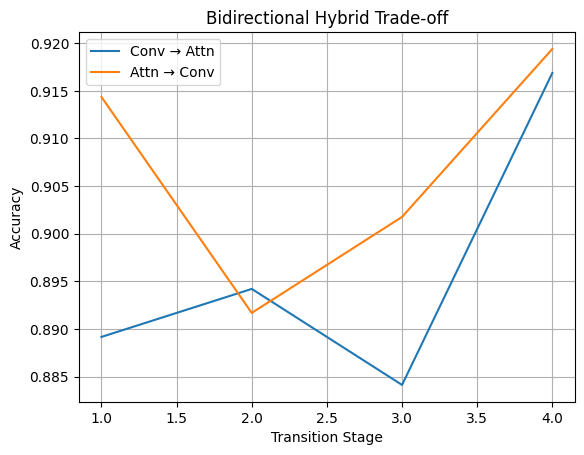

In [ ]:
plt.plot(results_conv_to_attn.keys(), results_conv_to_attn.values(), label="Conv → Attn")
plt.plot(results_attn_to_conv.keys(), results_attn_to_conv.values(), label="Attn → Conv")

plt.xlabel("Transition Stage")
plt.ylabel("Accuracy")
plt.title("Bidirectional Hybrid Trade-off")
plt.legend()
plt.grid()
plt.show()

In [ ]:
from PIL import ImageFilter

def add_blur(img):
    return img.filter(ImageFilter.GaussianBlur(5))

def evaluate_task(model, dataset, blur=False):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.eval()

    preds_all, labels_all = [], []

    for img, label in dataset:
        if blur:
            img = add_blur(transforms.ToPILImage()(img))
            img = transform(img)

        img = img.unsqueeze(0).to(device)

        pred = model(img).argmax(dim=1).item()
        preds_all.append(pred)
        labels_all.append(label)

    return accuracy_score(labels_all, preds_all)


In [ ]:
task_results = []

for stage in [1,2,3,4]:

    print(f"\nStage {stage}")

    # 🔹 Conv → Attention
    model_conv_attn = CoAtNetHybrid(transition_stage=stage, direction="conv_to_attn")
    model_conv_attn = train_model(model_conv_attn, train_loader)

    local_conv = evaluate_task(model_conv_attn, test_dataset, blur=False)
    global_conv = evaluate_task(model_conv_attn, test_dataset, blur=True)

    # 🔹 Attention → Conv
    model_attn_conv = CoAtNetHybrid(transition_stage=stage, direction="attn_to_conv")
    model_attn_conv = train_model(model_attn_conv, train_loader)

    local_attn = evaluate_task(model_attn_conv, test_dataset, blur=False)
    global_attn = evaluate_task(model_attn_conv, test_dataset, blur=True)

    task_results.append([
        stage,
        local_conv, global_conv,
        local_attn, global_attn
    ])

task_results = pd.DataFrame(task_results, columns=[
    "stage",
    "conv_local", "conv_global",
    "attn_local", "attn_global"
])

print(task_results)


Stage 1


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (101756928 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (101756928 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(



Stage 2


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (101756928 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (101756928 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(



Stage 3


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (101756928 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (101756928 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(



Stage 4


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (101756928 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (101756928 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


   stage  conv_local  conv_global  attn_local  attn_global
0      1    0.916877     0.430730    0.891688     0.380353
1      2    0.889169     0.397985    0.939547     0.508816
2      3    0.879093     0.367758    0.914358     0.443325
3      4    0.904282     0.476071    0.929471     0.483627


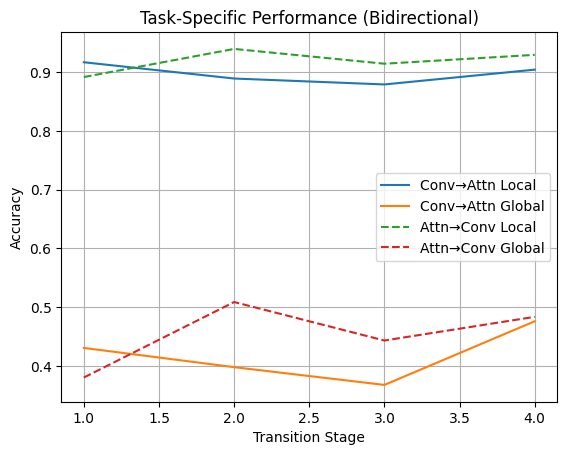

In [ ]:
plt.plot(task_results["stage"], task_results["conv_local"], label="Conv→Attn Local")
plt.plot(task_results["stage"], task_results["conv_global"], label="Conv→Attn Global")

plt.plot(task_results["stage"], task_results["attn_local"], linestyle='--', label="Attn→Conv Local")
plt.plot(task_results["stage"], task_results["attn_global"], linestyle='--', label="Attn→Conv Global")

plt.xlabel("Transition Stage")
plt.ylabel("Accuracy")
plt.title("Task-Specific Performance (Bidirectional)")
plt.legend()
plt.grid()
plt.show()